# Benchmark v2: 5-Way Constrained Borůvka Comparison

Compare five constrained-MST strategies + Kruskal (optimal) reference:

| # | Method | Guard | CL enforcement |
|---|--------|-------|----------------|
| 1 | **Mine – source-only** | `guard_mode=1` | Preventive bitset |
| 2 | **Mine – source+target** | `guard_mode=2` | Preventive bitset |
| 3 | **Mine – no guard** | `guard_mode=0` | Preventive bitset |
| 4 | **Rich – standard** | merge-then-fix | Linked-list pool |
| 5 | **Rich – banded** | merge-then-fix + band | Linked-list pool |
| 6 | **Kruskal (ref)** | N/A | Optimal CL-MSF |

Metrics: wall-clock time, #clusters, #rounds, MSF weight, CL violations.

In [2]:
# ── Section 1: Setup ──
import shutil, glob, sys, os, importlib, importlib.util, types, time
import numpy as np
import scipy.sparse as sp
from sklearn.datasets import make_moons
from sklearn.metrics import pairwise_distances

# Clear __pycache__ so we always get fresh JIT
for d in glob.glob(os.path.join(os.getcwd(), '**', '__pycache__'), recursive=True):
    if '.venv' not in d:
        shutil.rmtree(d, ignore_errors=True)
print('Cleared __pycache__')

# ── Bypass __init__.py JIT warmup ──
_pkg_dir = os.path.join(os.getcwd(), 'fast_hdbscan')
_stub = types.ModuleType('fast_hdbscan')
_stub.__path__ = [_pkg_dir]
_stub.__package__ = 'fast_hdbscan'
sys.modules['fast_hdbscan'] = _stub

def _load(mod_name):
    spec = importlib.util.spec_from_file_location(
        f'fast_hdbscan.{mod_name}',
        os.path.join(_pkg_dir, f'{mod_name}.py'),
        submodule_search_locations=[_pkg_dir],
    )
    mod = importlib.util.module_from_spec(spec)
    sys.modules[f'fast_hdbscan.{mod_name}'] = mod
    spec.loader.exec_module(mod)
    return mod

print('Loading submodules...')
_load('variables')
_load('disjoint_set')
_load('numba_kdtree')
_load('cluster_trees')
_cg = _load('core_graph')
_load('boruvka')
_precomputed = _load('precomputed')
_load('kruskal')
_load('nndescent')
_load('hdbscan')
_bc = _load('boruvka_constrained')
print('Done.')

# ── Pull out needed functions ──
# My constrained Borůvka (with guard_mode)
minimum_spanning_tree_constrained = _bc.minimum_spanning_tree_constrained

# Core-graph builder helpers (reuse from precomputed module)
validate_precomputed_sparse_graph = _precomputed.validate_precomputed_sparse_graph
_symmetrize_min_csr = _precomputed._symmetrize_min_csr
_core_distances_csr = _precomputed._core_distances_csr
_build_core_graph_csr = _precomputed._build_core_graph_csr
CoreGraph = _cg.CoreGraph
bridge_forest_with_inf = _precomputed.bridge_forest_with_inf

# Rich's Borůvka
boruvka_mst_cl = _cg.boruvka_mst_cl

# Kruskal (optimal reference)
compute_mst_from_precomputed_sparse_kruskal = _precomputed.compute_mst_from_precomputed_sparse_kruskal

# Clustering
clusters_from_spanning_tree = sys.modules['fast_hdbscan.hdbscan'].clusters_from_spanning_tree

print('All functions loaded.')

Cleared __pycache__
Loading submodules...
Done.
All functions loaded.


In [3]:
# ── Section 2: Helpers & Generators ──
SEED = 42

def make_cl_matrix(n, pairs):
    rows, cols = [], []
    for i, j in pairs:
        rows += [i, j]; cols += [j, i]
    return sp.csr_matrix((np.ones(len(rows), dtype=np.int8), (rows, cols)), shape=(n, n))

def generate_cl_pairs(y, n_pairs, seed=SEED):
    rng = np.random.default_rng(seed)
    classes = np.unique(y)
    pairs = set()
    for _ in range(n_pairs * 10):
        if len(pairs) >= n_pairs:
            break
        cls = rng.choice(classes)
        idx = np.where(y == cls)[0]
        if len(idx) < 2:
            continue
        i, j = rng.choice(idx, 2, replace=False)
        pairs.add((min(int(i), int(j)), max(int(i), int(j))))
    return sorted(pairs)

def gen_pinwheel(n, seed=SEED):
    rng = np.random.default_rng(seed)
    n_arms, Xs, ys = 5, [], []
    per_arm = n // n_arms
    for k in range(n_arms):
        m = per_arm + (1 if k < n % n_arms else 0)
        t = np.linspace(0, 1, m)
        angle = 2 * np.pi * k / n_arms
        r = 0.3 + 0.7 * t
        theta = angle + t * 1.5
        x = r * np.cos(theta) + rng.normal(0, 0.04, m)
        yy = r * np.sin(theta) + rng.normal(0, 0.04, m)
        Xs.append(np.column_stack([x, yy]))
        ys.append(np.full(m, k, dtype=np.int64))
    return np.vstack(Xs).astype(np.float64), np.concatenate(ys)

def gen_two_moons(n, seed=SEED):
    X, y = make_moons(n_samples=n, noise=0.08, random_state=seed)
    return X.astype(np.float64), y.astype(np.int64)

def gen_figure_eight(n, seed=SEED):
    rng = np.random.default_rng(seed)
    half = n // 2
    t1 = rng.uniform(0, 2 * np.pi, half)
    t2 = rng.uniform(0, 2 * np.pi, n - half)
    X = np.vstack([
        np.column_stack([np.cos(t1) - 1, np.sin(t1)]),
        np.column_stack([np.cos(t2) + 1, np.sin(t2)]),
    ]).astype(np.float64)
    X += rng.normal(0, 0.05, X.shape)
    y = np.array([0]*half + [1]*(n-half), dtype=np.int64)
    return X, y

def gen_chain(n, seed=SEED):
    """Chain of 4 Gaussian blobs."""
    rng = np.random.default_rng(seed)
    k = 4
    per = n // k
    Xs, ys = [], []
    for i in range(k):
        m = per + (1 if i < n % k else 0)
        center = np.array([i * 2.5, 0.0])
        Xs.append(rng.normal(center, 0.5, (m, 2)))
        ys.append(np.full(m, i, dtype=np.int64))
    return np.vstack(Xs).astype(np.float64), np.concatenate(ys)

def gen_star(n, seed=SEED):
    """Star: central blob + 5 satellite blobs."""
    rng = np.random.default_rng(seed)
    k = 6  # 1 center + 5 satellites
    per = n // k
    Xs, ys = [], []
    # Center
    m0 = per + (1 if 0 < n % k else 0)
    Xs.append(rng.normal([0, 0], 0.3, (m0, 2)))
    ys.append(np.full(m0, 0, dtype=np.int64))
    for i in range(1, k):
        m = per + (1 if i < n % k else 0)
        angle = 2 * np.pi * (i - 1) / (k - 1)
        center = np.array([3 * np.cos(angle), 3 * np.sin(angle)])
        Xs.append(rng.normal(center, 0.4, (m, 2)))
        ys.append(np.full(m, i, dtype=np.int64))
    return np.vstack(Xs).astype(np.float64), np.concatenate(ys)

print('Helpers ready.')

Helpers ready.


In [4]:
# ── Section 3: Runner functions ──
# Each returns (time_s, n_clusters, labels, n_rounds, msf_weight)

def _build_core_graph(X, ms=5):
    """Build a CoreGraph from dense feature matrix (shared by all runners)."""
    D = pairwise_distances(X, metric='euclidean').astype(np.float32)
    D_sparse = sp.csr_matrix(D)
    X_sym = _symmetrize_min_csr(D_sparse)
    nbrs, core_dists = _core_distances_csr(
        X_sym.data, X_sym.indices, X_sym.indptr, ms)
    weights, distances, cg_indices = _build_core_graph_csr(
        X_sym.data, X_sym.indices, X_sym.indptr, core_dists)
    return CoreGraph(weights, distances, cg_indices, X_sym.indptr), core_dists

def _edges_to_weight(edges):
    """Sum MSF edge weights (exclude +inf bridge edges)."""
    w = edges[:, 2]
    return float(np.sum(w[np.isfinite(w)]))

def _cluster_from_edges(edges, n, mcs=5):
    labels, probs, *_ = clusters_from_spanning_tree(edges, mcs)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    return n_clusters, labels


def run_mine(X, cl_indptr, cl_indices, guard_mode, ms=5, mcs=5):
    """My constrained Borůvka with configurable guard_mode."""
    t0 = time.perf_counter()
    cg, core_dists = _build_core_graph(X, ms)
    n_comp, pc, edges, n_rounds = minimum_spanning_tree_constrained(
        cg, cl_indptr, cl_indices, K=8, guard_mode=np.int32(guard_mode))
    if n_comp > 1:
        edges = bridge_forest_with_inf(edges, pc, X.shape[0])
    n_clusters, labels = _cluster_from_edges(edges, X.shape[0], mcs)
    elapsed = time.perf_counter() - t0
    return elapsed, n_clusters, labels, int(n_rounds), _edges_to_weight(edges)


def run_rich(X, cl_indptr, cl_indices, band_fraction=np.inf, ms=5, mcs=5):
    """Rich's Borůvka with merge-then-fix (optional banding)."""
    t0 = time.perf_counter()
    cg, core_dists = _build_core_graph(X, ms)
    n_comp, pc, edges, n_rounds = boruvka_mst_cl(
        cg, cl_indices, cl_indptr, band_fraction=band_fraction)
    if n_comp > 1:
        edges = bridge_forest_with_inf(edges, pc, X.shape[0])
    n_clusters, labels = _cluster_from_edges(edges, X.shape[0], mcs)
    elapsed = time.perf_counter() - t0
    return elapsed, n_clusters, labels, int(n_rounds), _edges_to_weight(edges)


def run_kruskal_ref(X, cl_sparse, ms=5, mcs=5):
    """Kruskal CL-MSF (optimal reference)."""
    t0 = time.perf_counter()
    D = pairwise_distances(X, metric='euclidean').astype(np.float64)
    D_sparse = sp.csr_matrix(D)
    mst_edges, _nbrs, _cd = compute_mst_from_precomputed_sparse_kruskal(
        D_sparse, ms, cannot_link=cl_sparse)
    n_clusters, labels = _cluster_from_edges(mst_edges, X.shape[0], mcs)
    elapsed = time.perf_counter() - t0
    return elapsed, n_clusters, labels, 1, _edges_to_weight(mst_edges)

print('Runners defined.')

Runners defined.


In [5]:
# ── Section 4: JIT warmup ──
print('Warming up JIT...', flush=True)
_Xw, _yw = gen_pinwheel(50)
_clp = generate_cl_pairs(_yw, 5)
_cls = make_cl_matrix(50, _clp)
_cli = np.asarray(_cls.indptr, dtype=np.int64)
_clx = np.asarray(_cls.indices, dtype=np.int32)

_ = run_mine(_Xw, _cli, _clx, guard_mode=1)
_ = run_mine(_Xw, _cli, _clx, guard_mode=2)
_ = run_mine(_Xw, _cli, _clx, guard_mode=0)
_ = run_rich(_Xw, _cli, _clx, band_fraction=np.inf)
_ = run_rich(_Xw, _cli, _clx, band_fraction=0.05)
_ = run_kruskal_ref(_Xw, _cls)
print('Warmup done.')

Warming up JIT...
Warmup done.


In [6]:
# ── Section 5: Main benchmark loop ──
SIZES = [100, 300, 500, 700, 900, 1100, 1300, 1500, 1750, 2000]
GEOMETRIES = {
    'pinwheel':     gen_pinwheel,
    'two_moons':    gen_two_moons,
    'figure_eight': gen_figure_eight,
    'chain':        gen_chain,
    'star':         gen_star,
}
N_REPEATS = 3
MS, MCS = 5, 5

# Method definitions: name -> (runner callable, call_style)
#   call_style: 'mine' -> run_mine(X, cli, clx, guard_mode=...)
#               'rich' -> run_rich(X, cli, clx, band_fraction=...)
#               'kruskal' -> run_kruskal_ref(X, cl_sparse)
METHOD_DEFS = [
    ('Mine src-only',   'mine',    dict(guard_mode=1)),
    ('Mine src+tgt',    'mine',    dict(guard_mode=2)),
    ('Mine no-guard',   'mine',    dict(guard_mode=0)),
    ('Rich standard',   'rich',    dict(band_fraction=np.inf)),
    ('Rich banded',     'rich',    dict(band_fraction=0.05)),
    ('Kruskal (ref)',   'kruskal', dict()),
]

results = []
t_start = time.perf_counter()

for geo_name, gen_fn in GEOMETRIES.items():
    for n in SIZES:
        X, y = gen_fn(n)
        n_cl = max(3, n // 20)
        cl_pairs = generate_cl_pairs(y, n_cl)
        cl_sparse = make_cl_matrix(n, cl_pairs)
        cl_indptr = np.asarray(cl_sparse.indptr, dtype=np.int64)
        cl_indices = np.asarray(cl_sparse.indices, dtype=np.int32)

        for method_name, call_style, kwargs in METHOD_DEFS:
            times, clusts, rounds_list, weights = [], [], [], []
            for _ in range(N_REPEATS):
                if call_style == 'mine':
                    t, nc, lbl, nr, w = run_mine(X, cl_indptr, cl_indices,
                                                  ms=MS, mcs=MCS, **kwargs)
                elif call_style == 'rich':
                    t, nc, lbl, nr, w = run_rich(X, cl_indptr, cl_indices,
                                                  ms=MS, mcs=MCS, **kwargs)
                else:  # kruskal
                    t, nc, lbl, nr, w = run_kruskal_ref(X, cl_sparse,
                                                         ms=MS, mcs=MCS)
                times.append(t)
                clusts.append(nc)
                rounds_list.append(nr)
                weights.append(w)

            results.append({
                'geometry': geo_name,
                'n': n,
                'method': method_name,
                'median_ms': np.median(times) * 1000,
                'n_clusters': int(np.median(clusts)),
                'n_rounds': int(np.median(rounds_list)),
                'msf_weight': np.median(weights),
            })
            print(f'{geo_name:>14} n={n:>5}  {method_name:<18} '
                  f'{np.median(times)*1000:8.1f} ms  k={int(np.median(clusts))}  '
                  f'r={int(np.median(rounds_list))}  w={np.median(weights):.1f}')

t_total = time.perf_counter() - t_start
print(f'\nDone. Total: {t_total:.1f}s  ({len(results)} data points)')

      pinwheel n=  100  Mine src-only          24.5 ms  k=2  r=3  w=21.3
      pinwheel n=  100  Mine src+tgt            7.9 ms  k=2  r=7  w=21.8
      pinwheel n=  100  Mine no-guard           6.5 ms  k=2  r=2  w=22.5
      pinwheel n=  100  Rich standard           4.6 ms  k=2  r=4  w=22.8
      pinwheel n=  100  Rich banded             9.9 ms  k=2  r=22  w=22.8
      pinwheel n=  100  Kruskal (ref)           4.8 ms  k=2  r=1  w=22.8
      pinwheel n=  300  Mine src-only          33.5 ms  k=12  r=3  w=25.9
      pinwheel n=  300  Mine src+tgt           40.5 ms  k=12  r=9  w=26.9
      pinwheel n=  300  Mine no-guard          38.1 ms  k=10  r=4  w=28.0
      pinwheel n=  300  Rich standard          26.0 ms  k=11  r=4  w=26.9
      pinwheel n=  300  Rich banded            33.5 ms  k=10  r=41  w=27.1
      pinwheel n=  300  Kruskal (ref)          31.7 ms  k=10  r=1  w=27.1
      pinwheel n=  500  Mine src-only          94.5 ms  k=14  r=5  w=32.2
      pinwheel n=  500  Mine src+tgt      

In [7]:
# ── Section 6: CL violation check ──
print('Checking CL violations on largest size per geometry...\n')
n_check = max(SIZES)

for geo_name, gen_fn in GEOMETRIES.items():
    X, y = gen_fn(n_check)
    n_cl = max(3, n_check // 20)
    cl_pairs = generate_cl_pairs(y, n_cl)
    cl_sparse = make_cl_matrix(n_check, cl_pairs)
    cl_indptr = np.asarray(cl_sparse.indptr, dtype=np.int64)
    cl_indices = np.asarray(cl_sparse.indices, dtype=np.int32)

    print(f'--- {geo_name} (n={n_check}, CL pairs={n_cl}) ---')
    for method_name, call_style, kwargs in METHOD_DEFS:
        if call_style == 'mine':
            _, _, labels, _, _ = run_mine(X, cl_indptr, cl_indices,
                                          ms=MS, mcs=MCS, **kwargs)
        elif call_style == 'rich':
            _, _, labels, _, _ = run_rich(X, cl_indptr, cl_indices,
                                          ms=MS, mcs=MCS, **kwargs)
        else:
            _, _, labels, _, _ = run_kruskal_ref(X, cl_sparse, ms=MS, mcs=MCS)

        # Check: are any CL-paired points in the same non-noise cluster?
        violations = 0
        for i, j in cl_pairs:
            if labels[i] >= 0 and labels[i] == labels[j]:
                violations += 1
        status = 'CLEAN' if violations == 0 else f'{violations} VIOLATIONS'
        print(f'  {method_name:<18} -> {status}')
    print()

Checking CL violations on largest size per geometry...

--- pinwheel (n=2000, CL pairs=100) ---
  Mine src-only      -> CLEAN
  Mine src+tgt       -> CLEAN
  Mine no-guard      -> CLEAN
  Rich standard      -> CLEAN
  Rich banded        -> CLEAN
  Kruskal (ref)      -> CLEAN

--- two_moons (n=2000, CL pairs=100) ---
  Mine src-only      -> CLEAN
  Mine src+tgt       -> CLEAN
  Mine no-guard      -> CLEAN
  Rich standard      -> CLEAN
  Rich banded        -> CLEAN
  Kruskal (ref)      -> CLEAN

--- figure_eight (n=2000, CL pairs=100) ---
  Mine src-only      -> CLEAN
  Mine src+tgt       -> CLEAN
  Mine no-guard      -> CLEAN
  Rich standard      -> CLEAN
  Rich banded        -> CLEAN
  Kruskal (ref)      -> CLEAN

--- chain (n=2000, CL pairs=100) ---
  Mine src-only      -> CLEAN
  Mine src+tgt       -> CLEAN
  Mine no-guard      -> CLEAN
  Rich standard      -> CLEAN
  Rich banded        -> CLEAN
  Kruskal (ref)      -> CLEAN

--- star (n=2000, CL pairs=100) ---
  Mine src-only      -

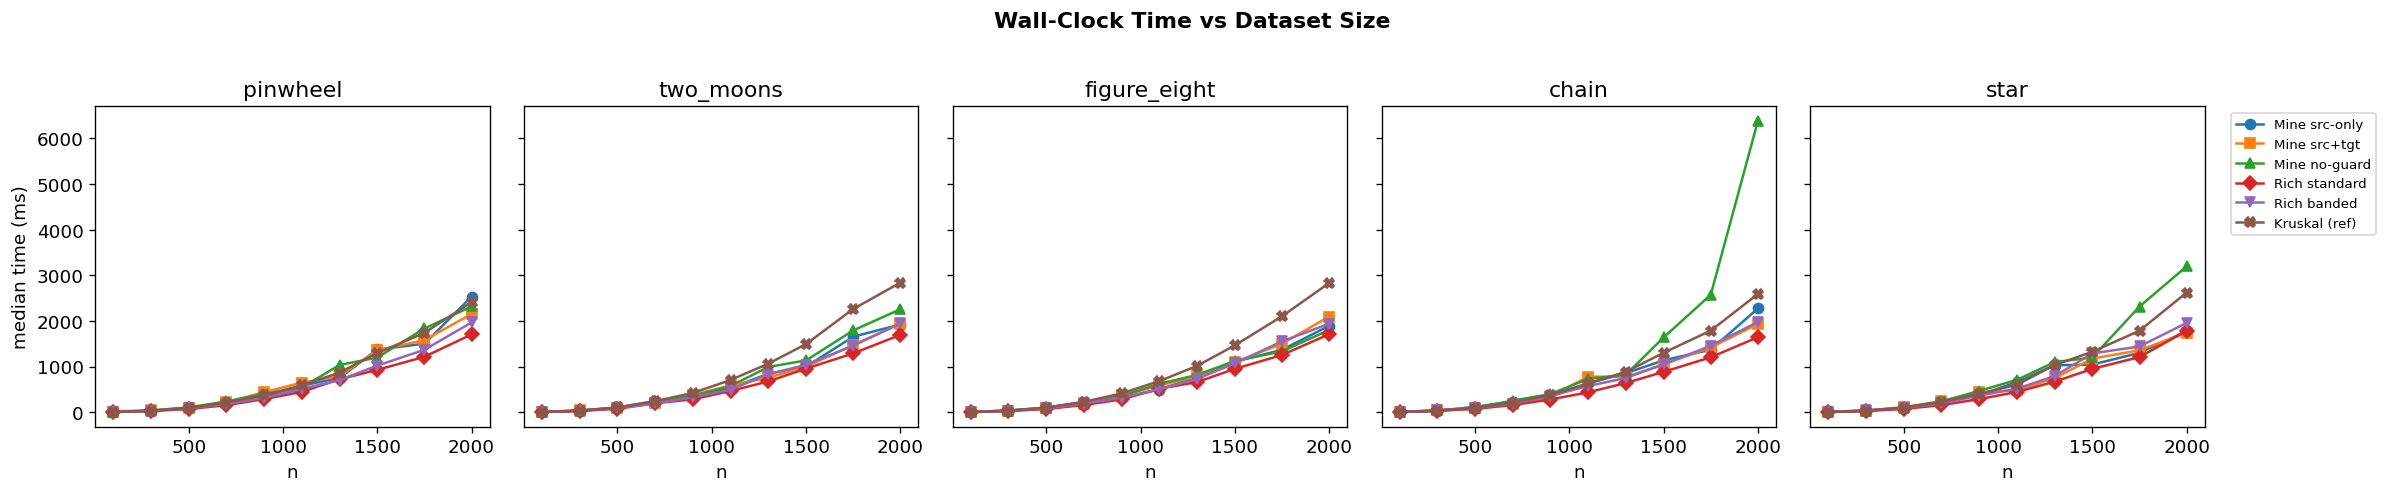

In [8]:
# ── Section 7: Visualizations ──
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 11, 'figure.dpi': 120})

import pandas as pd
df = pd.DataFrame(results)

method_colors = {
    'Mine src-only':  '#1f77b4',
    'Mine src+tgt':   '#ff7f0e',
    'Mine no-guard':  '#2ca02c',
    'Rich standard':  '#d62728',
    'Rich banded':    '#9467bd',
    'Kruskal (ref)':  '#8c564b',
}
method_markers = {
    'Mine src-only':  'o',
    'Mine src+tgt':   's',
    'Mine no-guard':  '^',
    'Rich standard':  'D',
    'Rich banded':    'v',
    'Kruskal (ref)':  'X',
}

# ── Plot 1: Time vs n (one subplot per geometry) ──
geos = list(GEOMETRIES.keys())
fig, axes = plt.subplots(1, len(geos), figsize=(4*len(geos), 4), sharey=True)
if len(geos) == 1:
    axes = [axes]
for ax, geo in zip(axes, geos):
    sub = df[df.geometry == geo]
    for method in df.method.unique():
        ms = sub[sub.method == method]
        ax.plot(ms.n, ms.median_ms, marker=method_markers[method],
                color=method_colors[method], label=method, linewidth=1.5)
    ax.set_title(geo)
    ax.set_xlabel('n')
    if ax == axes[0]:
        ax.set_ylabel('median time (ms)')
axes[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
fig.suptitle('Wall-Clock Time vs Dataset Size', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

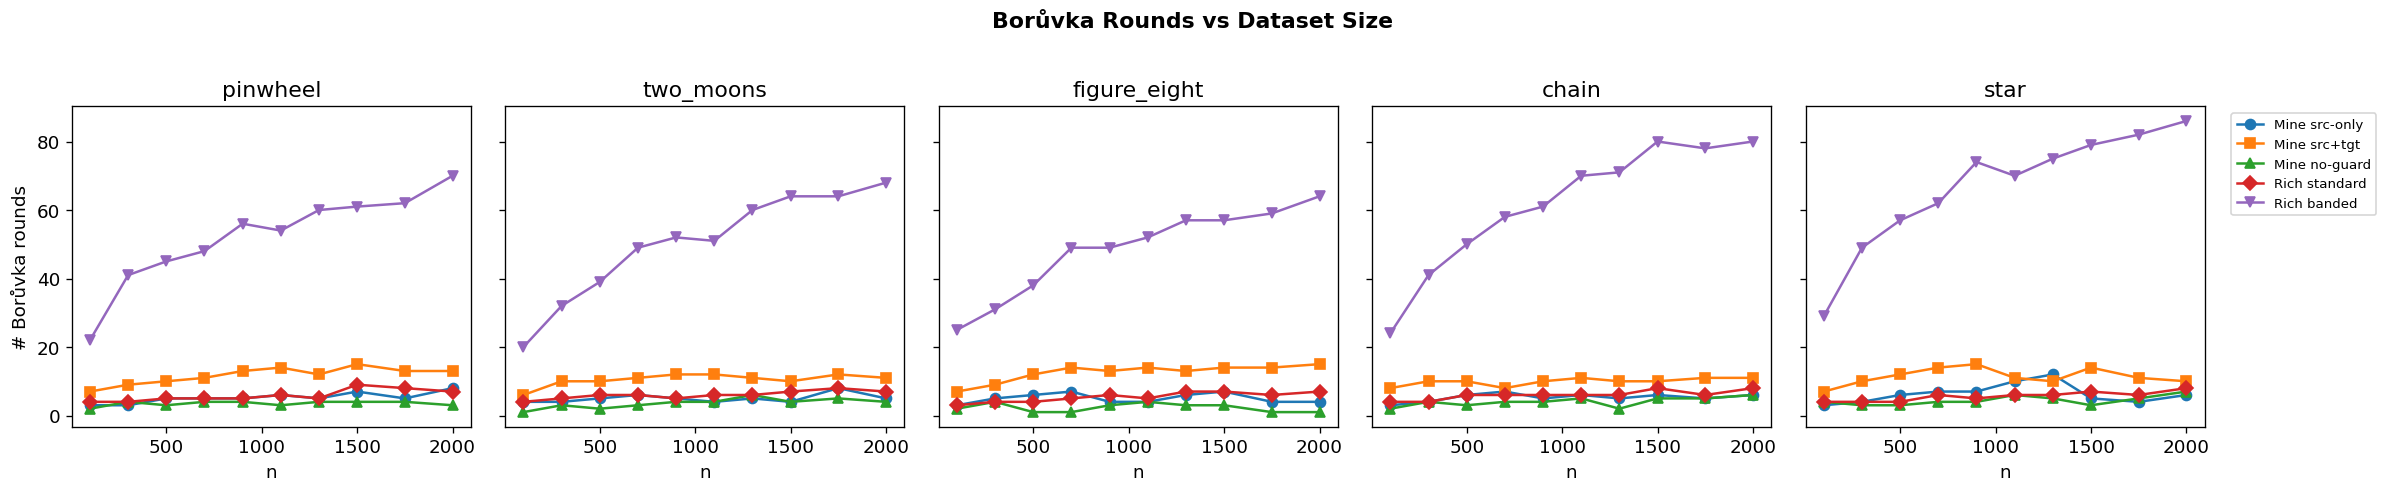

In [9]:
# ── Plot 2: Rounds vs n ──
fig, axes = plt.subplots(1, len(geos), figsize=(4*len(geos), 4), sharey=True)
if len(geos) == 1:
    axes = [axes]
for ax, geo in zip(axes, geos):
    sub = df[df.geometry == geo]
    for method in df.method.unique():
        if method == 'Kruskal (ref)':
            continue  # Kruskal always 1 round
        ms = sub[sub.method == method]
        ax.plot(ms.n, ms.n_rounds, marker=method_markers[method],
                color=method_colors[method], label=method, linewidth=1.5)
    ax.set_title(geo)
    ax.set_xlabel('n')
    if ax == axes[0]:
        ax.set_ylabel('# Borůvka rounds')
axes[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
fig.suptitle('Borůvka Rounds vs Dataset Size', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

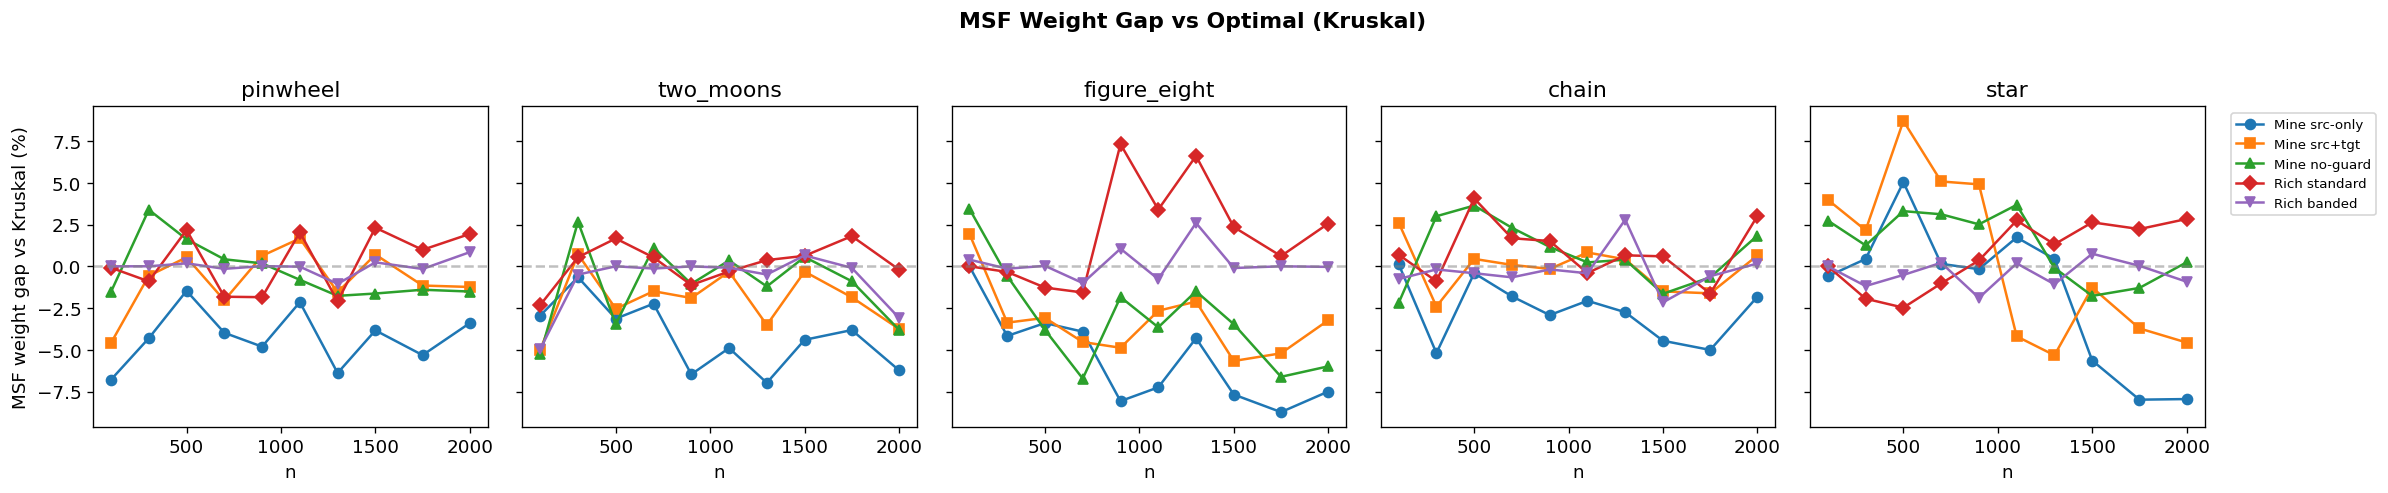

In [10]:
# ── Plot 3: MSF weight gap vs Kruskal (optimal) ──
# For each (geometry, n): weight_gap = (method_weight - kruskal_weight) / kruskal_weight * 100
kruskal_weights = df[df.method == 'Kruskal (ref)'][['geometry', 'n', 'msf_weight']].copy()
kruskal_weights.rename(columns={'msf_weight': 'kruskal_weight'}, inplace=True)
df2 = df.merge(kruskal_weights, on=['geometry', 'n'])
df2['weight_gap_pct'] = (df2.msf_weight - df2.kruskal_weight) / df2.kruskal_weight * 100

fig, axes = plt.subplots(1, len(geos), figsize=(4*len(geos), 4), sharey=True)
if len(geos) == 1:
    axes = [axes]
for ax, geo in zip(axes, geos):
    sub = df2[df2.geometry == geo]
    for method in df2.method.unique():
        if method == 'Kruskal (ref)':
            continue  # gap is 0 by definition
        ms = sub[sub.method == method]
        ax.plot(ms.n, ms.weight_gap_pct, marker=method_markers[method],
                color=method_colors[method], label=method, linewidth=1.5)
    ax.axhline(0, color='grey', linestyle='--', alpha=0.5)
    ax.set_title(geo)
    ax.set_xlabel('n')
    if ax == axes[0]:
        ax.set_ylabel('MSF weight gap vs Kruskal (%)')
axes[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
fig.suptitle('MSF Weight Gap vs Optimal (Kruskal)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

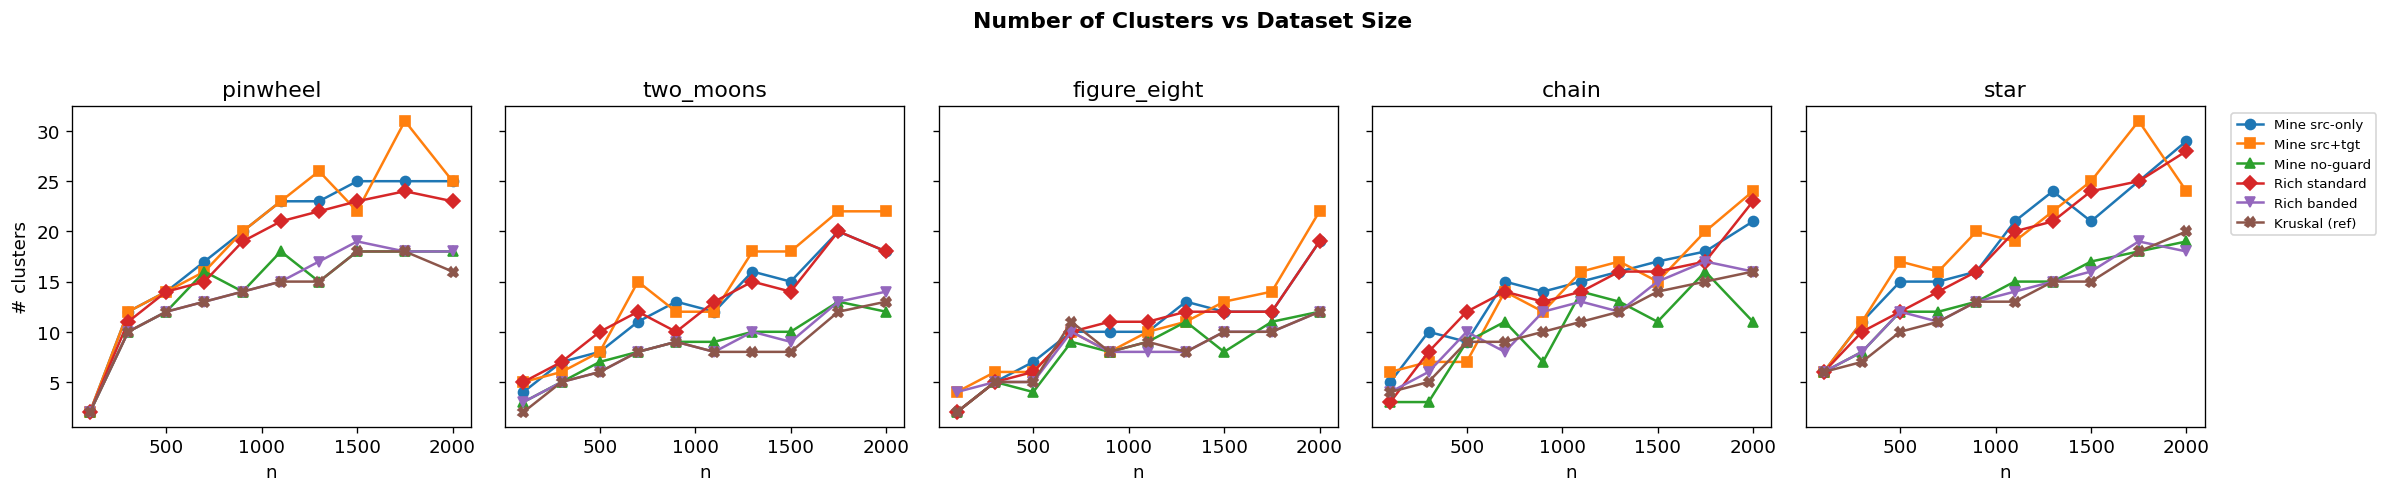

In [11]:
# ── Plot 4: Clusters vs n ──
fig, axes = plt.subplots(1, len(geos), figsize=(4*len(geos), 4), sharey=True)
if len(geos) == 1:
    axes = [axes]
for ax, geo in zip(axes, geos):
    sub = df[df.geometry == geo]
    for method in df.method.unique():
        ms = sub[sub.method == method]
        ax.plot(ms.n, ms.n_clusters, marker=method_markers[method],
                color=method_colors[method], label=method, linewidth=1.5)
    ax.set_title(geo)
    ax.set_xlabel('n')
    if ax == axes[0]:
        ax.set_ylabel('# clusters')
axes[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
fig.suptitle('Number of Clusters vs Dataset Size', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [12]:
# ── Section 8: Summary table ──
print('=== Summary (aggregated across all geometries) ===\n')
summary = df.groupby('method').agg(
    mean_ms=('median_ms', 'mean'),
    max_ms=('median_ms', 'max'),
    mean_rounds=('n_rounds', 'mean'),
    mean_clusters=('n_clusters', 'mean'),
    mean_weight=('msf_weight', 'mean'),
).round(2)
print(summary.to_string())

# Weight gap summary
print('\n=== MSF Weight Gap vs Kruskal (%) ===\n')
gap_summary = df2[df2.method != 'Kruskal (ref)'].groupby('method').agg(
    mean_gap=('weight_gap_pct', 'mean'),
    max_gap=('weight_gap_pct', 'max'),
    min_gap=('weight_gap_pct', 'min'),
).round(3)
print(gap_summary.to_string())

=== Summary (aggregated across all geometries) ===

               mean_ms   max_ms  mean_rounds  mean_clusters  mean_weight
method                                                                  
Kruskal (ref)   835.72  2840.96         1.00          10.50       104.45
Mine no-guard   878.43  6383.70         3.56          10.78       104.37
Mine src+tgt    671.88  2155.11        11.20          15.24       103.38
Mine src-only   680.19  2534.07         5.38          14.66       100.84
Rich banded     645.71  1978.08        55.50          10.96       104.18
Rich standard   557.20  1786.55         5.76          14.20       105.56

=== MSF Weight Gap vs Kruskal (%) ===

               mean_gap  max_gap  min_gap
method                                   
Mine no-guard    -0.461    3.679   -6.727
Mine src+tgt     -1.107    8.706   -5.672
Mine src-only    -3.603    5.042   -8.734
Rich banded      -0.273    2.793   -4.955
Rich standard     0.798    7.317   -2.477
